<a href="https://colab.research.google.com/github/rachidahebie-cloud/churnradar/blob/main/churnradar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse du Churn Client — Telco Customer Churn

**Membres du groupe :** Tié Rachida HEBIE

**Dataset :** Telco Customer Churn (IBM Sample Dataset)
**Source :** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## Introduction

La rétention client est un enjeu majeur pour les entreprises de télécommunications,
où le coût d'acquisition d'un nouveau client est généralement bien plus élevé que
celui de la fidélisation d'un client existant. Ce projet analyse un jeu de données
de 7 043 clients d'une entreprise de télécommunications fictive, incluant leurs
caractéristiques démographiques, les services souscrits, et leur statut de
désabonnement (churn). L'objectif est d'identifier les facteurs associés au churn
afin de fournir des pistes d'action concrètes pour améliorer la rétention.

## Problème et objectifs analytiques

**Question de recherche principale :**
Quels sont les facteurs qui influencent le plus la probabilité qu'un client se
désabonne (churn), et comment ces facteurs peuvent-ils orienter une stratégie
de rétention ?

**Type de problème analytique :**
Ce projet combine une analyse exploratoire (EDA) descriptive et relationnelle,
avec un volet optionnel de classification supervisée (prédiction binaire du churn :
Yes/No).

**Sous-questions :**
- Quelles variables catégorielles (type de contrat, méthode de paiement, services
  souscrits) sont les plus associées au churn ?
- Le profil démographique (senior ou non) influence-t-il le taux de désabonnement ?
- L'ancienneté du client (tenure) et les montants facturés (MonthlyCharges,
  TotalCharges) sont-ils liés à la probabilité de churn ?

**Pertinence opérationnelle :**
Les résultats de cette analyse peuvent permettre à l'entreprise de cibler des
actions de rétention (offres, accompagnement) vers les segments de clients les
plus à risque, plutôt que d'appliquer une stratégie générique coûteuse et peu
efficace.

In [ ]:
import pandas as pd

# Charger le dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# nombre de valeurs non null
print(df.count())

# Options d'affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Premier aperçu
print("Dimensions :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

print("\nPremières lignes :")
print(df.head())

print("\nInformations générales :")
print(df.info())

print("\nRépartition de la variable cible :")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

print("\nStatistiques descriptives :")
print(df.describe())

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64
Dimensions : (7043, 21)

Colonnes :
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Premières lignes :
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     M

Analyse de totalCharge qui devrait etre un numérique mais qui est ici un object .Il faudra donc vérifier qu'il n'y pas de ligne vide  

Analyse des variables catégorielles

In [ ]:
categorical_cols = [
    col for col in df.select_dtypes(include="object").columns
    if col not in ["customerID", "TotalCharges", "Churn"]
]

print(categorical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
for col in categorical_cols:
    print("\n" + "=" * 50)
    print(f"Variable : {col}")

    print("\nRépartition :")
    print(df[col].value_counts())

    print("\nPourcentage :")
    print((df[col].value_counts(normalize=True) * 100).round(2))

    print("\nTaux de churn par modalité :")
    print(
        (pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        ) * 100).round(2)
    )


Variable : gender

Répartition :
gender
Male      3555
Female    3488
Name: count, dtype: int64

Pourcentage :
gender
Male      50.48
Female    49.52
Name: proportion, dtype: float64

Taux de churn par modalité :
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

Variable : Partner

Répartition :
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Pourcentage :
Partner
No     51.7
Yes    48.3
Name: proportion, dtype: float64

Taux de churn par modalité :
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66

Variable : Dependents

Répartition :
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Pourcentage :
Dependents
No     70.04
Yes    29.96
Name: proportion, dtype: float64

Taux de churn par modalité :
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

Variable : PhoneService

Répartition :
PhoneService
Yes    6361
No      682
Name: count, dtype: 

Le churn semble particulièrement élevé chez les clients ayant des contrats mensuels, utilisant l'Electronic check, ayant une connexion Fiber optic et ne disposant pas de certains services complémentaires comme OnlineSecurity ou TechSupport.

On s'intéresse maintanant au variable non catégirielle

 SeniorCitizen (Senior = 1 , non-senior=0)

In [ ]:
print(df["SeniorCitizen"].value_counts())

print(df["SeniorCitizen"].value_counts(normalize=True) * 100)

print(
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    ) * 100
)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
SeniorCitizen
0    83.785319
1    16.214681
Name: proportion, dtype: float64
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


Les seniors sont davantage suscveptique de ce désabonner

On s'intéresse maintenant tenure

In [ ]:
print(df.groupby("Churn")["tenure"].describe())

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


Les clients qui se désabonnent ont une ancienneté nettement plus faible (médiane ~10 mois) que ceux qui restent (~38 mois). Les nouveaux clients sont donc les plus à risque de churn, ce qui suggère un enjeu d'accompagnement dans les premiers mois de la relation client.

On s'interesse maintenant au montant payé par moius pour un abonnement MonthlyCharge

In [ ]:
print(df.groupby("Churn")["MonthlyCharges"].describe())

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


Les gens qui ne se désabonnent pas ont une charge mensuelle moins élévé que les gens qui se qui se désabonnent . On peut donc supposer que les clients ayant des charges mensuelles plus élevées sont davantage susceptibles de se désabonner.

On va maintenant traiter TotalCharges

In [ ]:
print(df["TotalCharges"].unique()[:20])

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Valeurs manquantes après conversion :")
print(df["TotalCharges"].isna().sum())

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']
Valeurs manquantes après conversion :
11


Le dataset contient 11 valeurs manquantes dans TotalCharges, détectées après conversion de la variable en numérique.

In [ ]:
print(df[df["TotalCharges"].isna()])

      customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport  \
488   4472-LVYGI  Female              0     Yes        Yes       0           No  No phone service             DSL                  Yes                   No                  Yes                  Yes   
753   3115-CZMZD    Male              0      No        Yes       0          Yes                No              No  No internet service  No internet service  No internet service  No internet service   
936   5709-LVOEQ  Female              0     Yes        Yes       0          Yes                No             DSL                  Yes                  Yes                  Yes                   No   
1082  4367-NUYAO    Male              0     Yes        Yes       0          Yes               Yes              No  No internet service  No internet service  No internet service  No internet servic

In [ ]:
print(df[df["TotalCharges"].isna()][
    ["tenure", "MonthlyCharges", "Contract", "Churn"]
])

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# tout rremplacé par 0
print(df["TotalCharges"].isna().sum())

      tenure  MonthlyCharges  Contract Churn
488        0           52.55  Two year    No
753        0           20.25  Two year    No
936        0           80.85  Two year    No
1082       0           25.75  Two year    No
1340       0           56.05  Two year    No
3331       0           19.85  Two year    No
3826       0           25.35  Two year    No
4380       0           20.00  Two year    No
5218       0           19.70  One year    No
6670       0           73.35  Two year    No
6754       0           61.90  Two year    No
0


Les 11 valeurs manquantes correspondent toutes à des clients avec tenure = 0, c'est-à-dire des clients nouvellement inscrits n'ayant pas encore été facturés. Remplacer par 0 est donc logiquement justifié plutôt que d'imputer par la moyenne ou de supprimer ces lignes.

In [ ]:
print(df.groupby("Churn")["TotalCharges"].describe())

        count         mean          std    min    25%       50%      75%      max
Churn                                                                            
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85  8672.45
Yes    1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30  8684.80


Les clients qui se désabonnent ont une charge totale nettement plus faible que ceux qui restent, avec une médiane de 703,55 € contre 1 679,53 €. Cette différence peut s'expliquer en partie par leur ancienneté plus faible : les clients qui se désabonnent restent généralement moins longtemps dans l'entreprise et ont donc moins de temps pour accumuler des charges

les visualisations

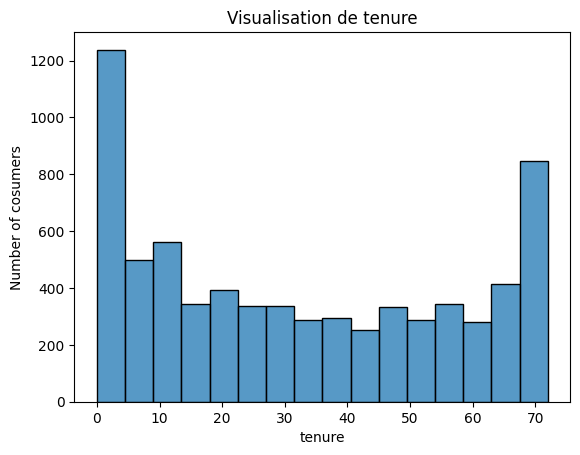

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data = df, x="tenure")

plt.title("Visualisation de tenure")
plt.xlabel("tenure")
plt.ylabel("Number of cosumers")

plt.show()

la distribution est bimodale, avec une forte concentration de clients à très faible ancienneté et un second groupe à ancienneté maximale.

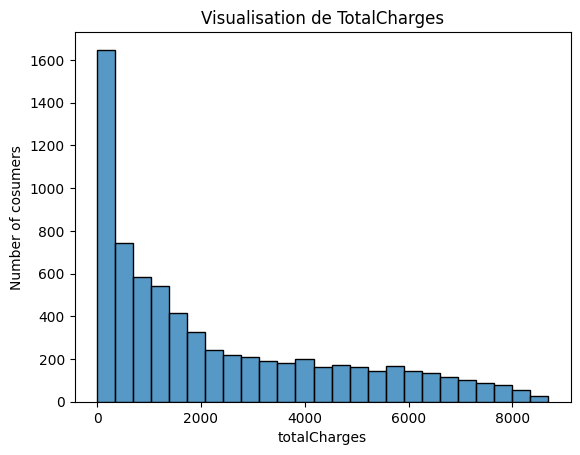

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data = df, x="TotalCharges")

plt.title("Visualisation de TotalCharges")
plt.xlabel("totalCharges")
plt.ylabel("Number of cosumers")

plt.show()

Le graphique montre que la majorité des clients ont un TotalCharges faible, avec une distribution fortement asymétrique à droite : le nombre de clients diminue progressivement à mesure que le montant total augmente. Cette forme s'explique en grande partie par la distribution de tenure observée précédemment : de nombreux clients ayant une faible ancienneté, ils n'ont mécaniquement pas eu le temps d'accumuler des charges élevées, indépendamment de leur charge mensuelle.

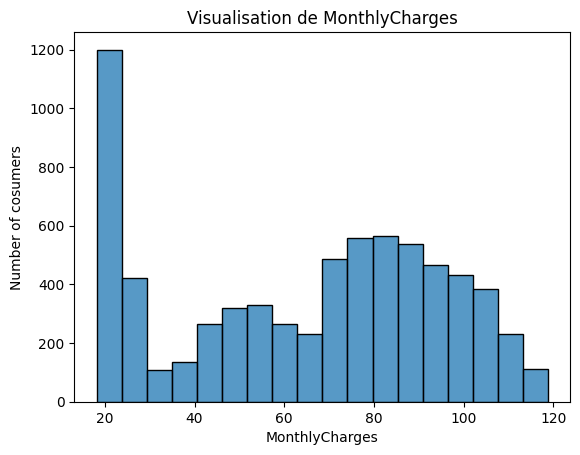

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data = df, x="MonthlyCharges")

plt.title("Visualisation de MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Number of cosumers")

plt.show()

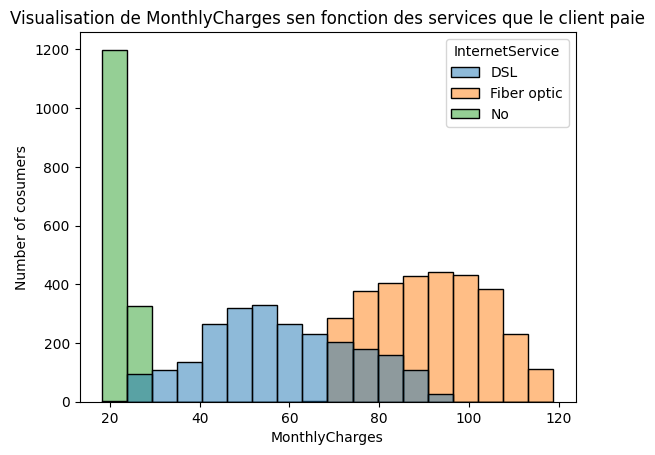

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data = df, x="MonthlyCharges", hue="InternetService")

plt.title("Visualisation de MonthlyCharges sen fonction des services que le client paie")
plt.xlabel("MonthlyCharges")
plt.ylabel("Number of cosumers")

plt.show()

Ce graphique confirme parfaitement l'hypothèse formulée précédemment sur l'origine de la distribution bimodale de MonthlyCharges. On voit clairement que le premier pic autour de 20 dollars correspond presque exclusivement aux clients sans service internet, en vert, ce qui est logique puisqu'ils ne paient que le téléphone. Le second groupe, situé entre 70 et 100 dollars, est majoritairement composé de clients ayant la fibre optique, en orange, dont les charges mensuelles sont nettement plus élevées à cause du coût plus important de ce service. Les clients avec une connexion DSL, en bleu, se situent dans une zone intermédiaire, avec des charges mensuelles généralement comprises entre 40 et 70 dollars. On peut donc conclure que la bimodalité observée n'est pas due au hasard mais reflète directement le type de service internet souscrit par les clients, chaque groupe technologique ayant une structure de prix propre. Ce résultat est particulièrement intéressant si on le met en lien avec les taux de churn calculés précédemment, puisque les clients fibre optique, qui paient le plus cher, sont aussi ceux qui présentent le taux de désabonnement le plus élevé avec 41,89 pourcent, contre 18,96 pourcent pour les clients DSL et seulement 7,40 pourcent pour les clients sans internet. Cela suggère un lien possible entre le niveau de charge mensuelle et la probabilité de churn, les clients payant plus cher étant aussi les plus susceptibles de se désabonner.

Boxplot 1 : tenure selon Churn

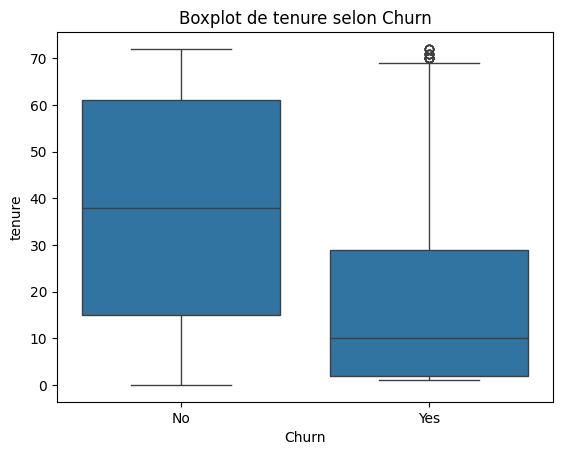

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Boxplot de tenure selon Churn")
plt.show()

Le boxplot confirme visuellement l'écart déjà observé dans les statistiques descriptives : la médiane d'ancienneté des clients qui résilient (10 mois) est nettement inférieure à celle des clients qui restent (38 mois), avec un faible chevauchement entre les deux distributions. Les clients qui restent affichent également une dispersion plus large, incluant aussi bien des clients récents que très anciens, tandis que les clients qui résilient se concentrent majoritairement sur de faibles anciennetés. On note toutefois quelques valeurs atypiques (outliers) : un petit nombre de clients résilient après plus de 65 mois d'ancienneté, ce qui reste rare mais mérite d'être signalé comme exception au profil général.

Boxplot 2 : MonthlyCharges selon Churn

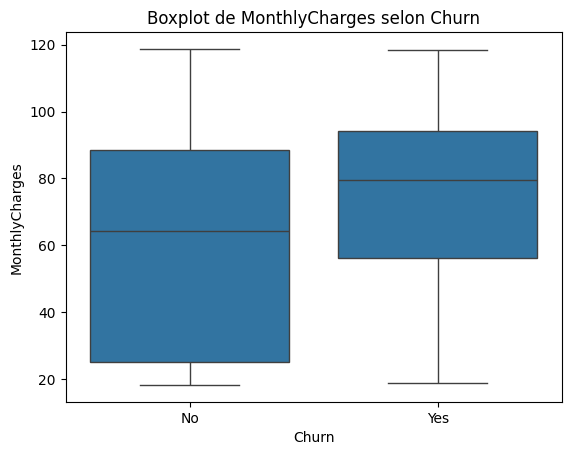

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Boxplot de MonthlyCharges selon Churn")
plt.show()

On observe que les clients qui se désabonnent ont des charges mensuelles plus élevées (médiane ~80)que ceux qui restent(m
e
ˊ
diane 64), confirmant les statistiques calculées précédemment (moyennes de 74$ contre 61$). Contrairement aux boxplots de tenure et TotalCharges, c'est ici le groupe "Yes" qui est positionné plus haut. Le chevauchement entre les deux boîtes reste important, ce qui indique que la charge mensuelle seule ne permet pas de distinguer parfaitement les deux groupes — de nombreux clients avec une charge élevée restent tout de même abonnés. On note aussi que la boîte "No" est plus étalée que la boîte "Yes", signe que les clients fidèles ont des profils de charges mensuelles bien plus variés, alors que les clients qui résilient se concentrent davantage dans le haut de la fourchette de prix. Aucun outlier marquant n'est observé sur cette variable, contrairement à TotalCharges.

Boxplot 3 : TotalCharges selon Churn

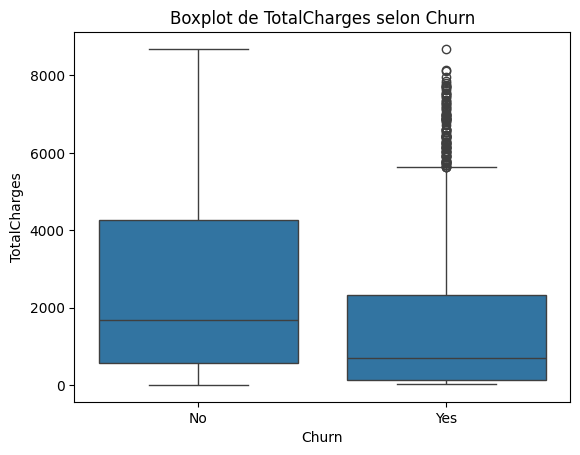

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Boxplot de TotalCharges selon Churn")
plt.show()

Le boxplot confirme que les clients ayant résilié ont un TotalCharges médian nettement plus faible (~704
)queceuxquisontrestes( 1680), cohérent avec leur ancienneté généralement plus courte. La boîte des clients restés est également plus étalée, reflétant une plus grande diversité de profils (nouveaux et anciens clients confondus). On observe cependant un nombre important d'outliers au-dessus du groupe "Yes", jusqu'à environ 8000$ : il s'agit de clients ayant accumulé une charge totale élevée — donc probablement une ancienneté ou des charges mensuelles importantes — mais ayant tout de même résilié. Ce sous-groupe s'écarte du profil typique du churner et pourrait mériter une investigation plus poussée (par exemple, vérifier si ces clients ont subi une hausse tarifaire ou un problème de service juste avant leur départ, information non disponible dans ce dataset).

Affichage des variable catégorielle en barres plots horizontal

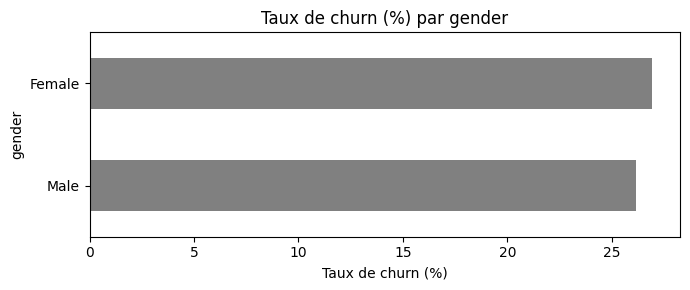

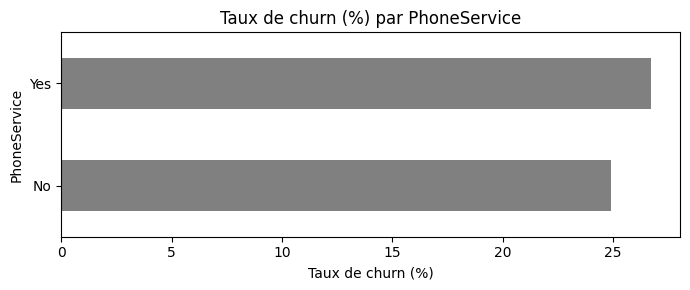

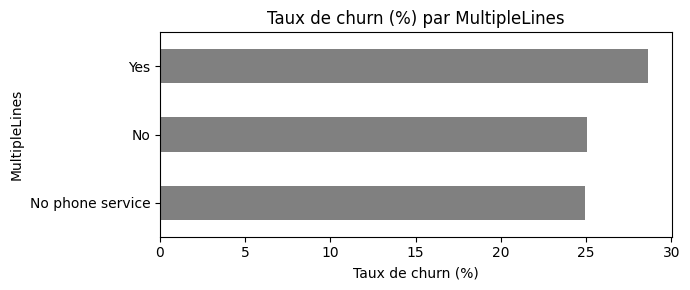

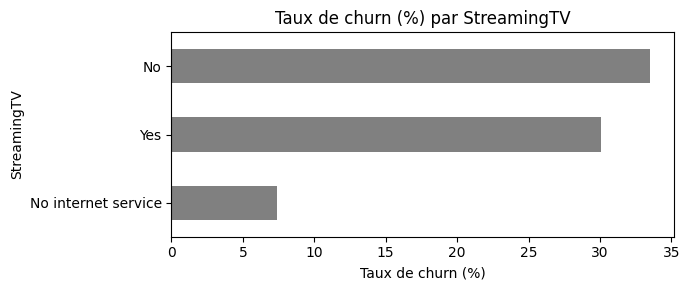

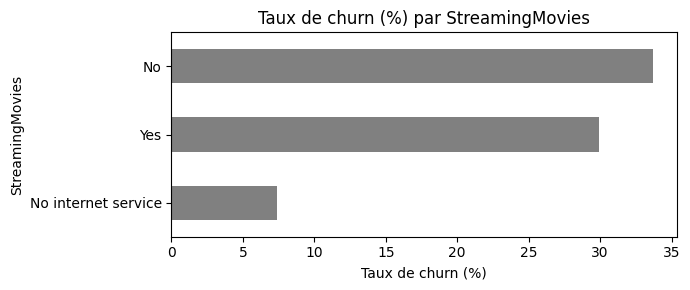

In [ ]:
variables_peu_discriminantes = ["gender", "PhoneService", "MultipleLines", "StreamingTV", "StreamingMovies"]

for col in variables_peu_discriminantes:
    churn_rate = (
        pd.crosstab(df[col], df["Churn"], normalize="index")["Yes"] * 100
    ).sort_values()

    plt.figure(figsize=(7, 3))
    churn_rate.plot(kind="barh", color="gray")
    plt.title(f"Taux de churn (%) par {col}")
    plt.xlabel("Taux de churn (%)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Certaines caractéristiques montrent peu ou pas de lien avec le churn. Le genre (gender) affiche un taux de désabonnement quasi identique entre hommes et femmes (26,9% vs 26,2%), de même que la possession d'un service téléphonique (PhoneService) ou de plusieurs lignes (MultipleLines), avec des écarts inférieurs à 4 points. Les services de streaming (StreamingTV, StreamingMovies) présentent un écart un peu plus visible mais qui reste modeste (environ 3 à 4 points entre "Yes" et "No"), bien moins marqué que pour les variables contractuelles ou techniques (Contract, InternetService, OnlineSecurity). Cela suggère que ces caractéristiques ne constituent pas des facteurs déterminants du désabonnement, contrairement au type de contrat, à la méthode de paiement ou à la présence de services de sécurité/support technique.

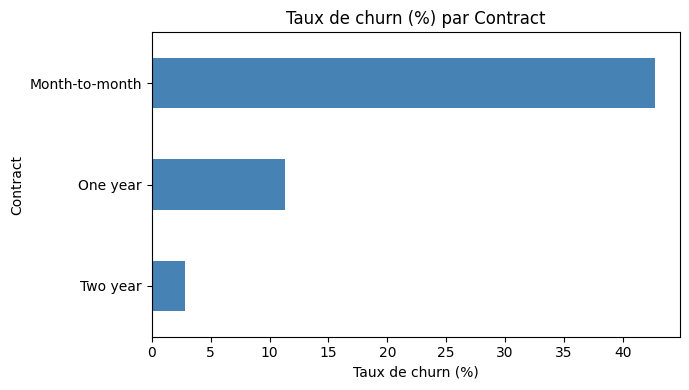

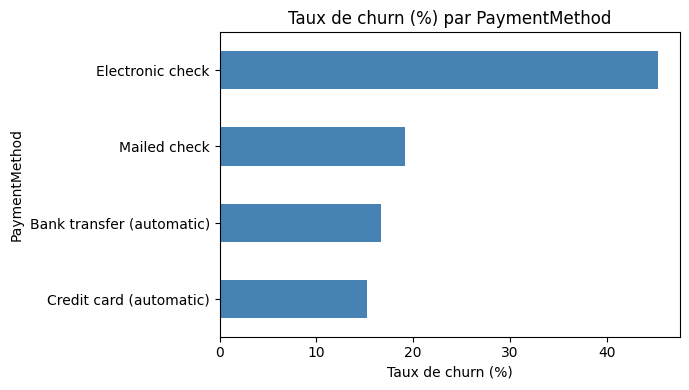

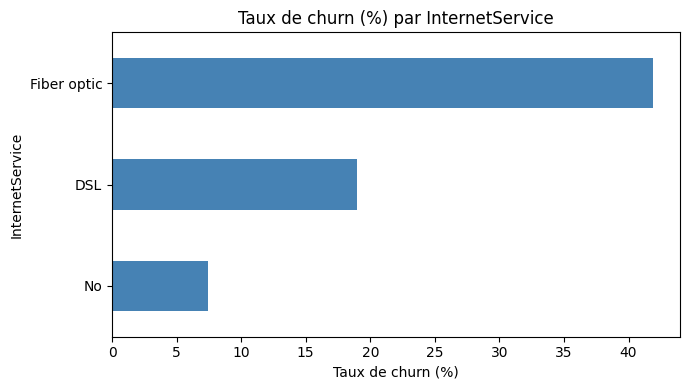

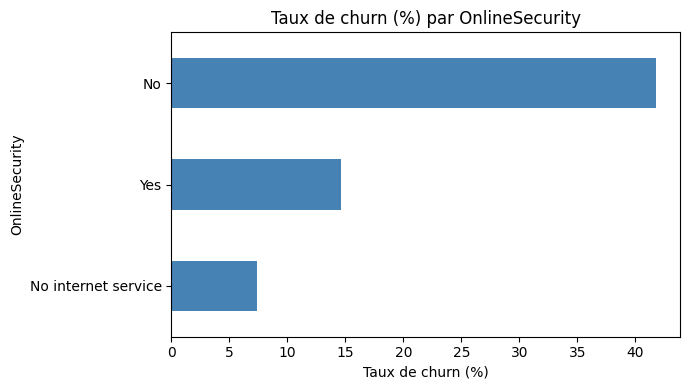

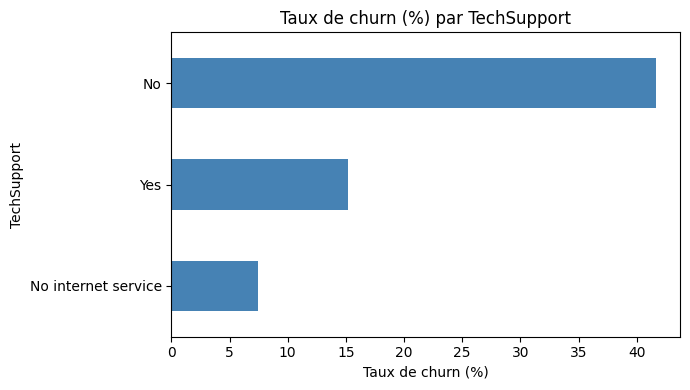

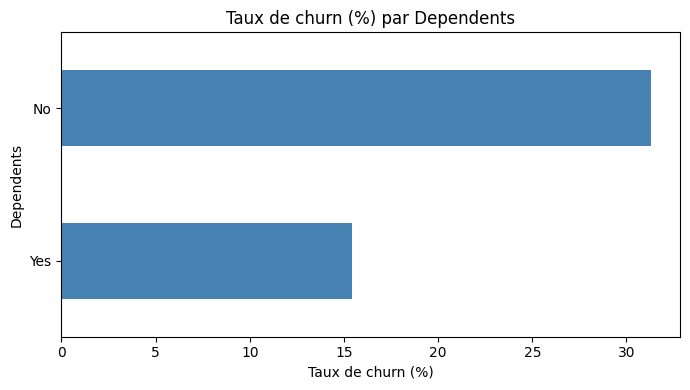

In [ ]:
variables_discriminantes = ["Contract", "PaymentMethod", "InternetService", "OnlineSecurity", "TechSupport" , "Dependents"]

for col in variables_discriminantes:
    churn_rate = (
        pd.crosstab(df[col], df["Churn"], normalize="index")["Yes"] * 100
    ).sort_values()

    plt.figure(figsize=(7, 4))
    churn_rate.plot(kind="barh", color="steelblue")
    plt.title(f"Taux de churn (%) par {col}")
    plt.xlabel("Taux de churn (%)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Ces graphiques confirment visuellement les tendances identifiées dans l'analyse textuelle précédente. Les six variables retenues (Contract, PaymentMethod, InternetService, OnlineSecurity, TechSupport, Dependents) présentent toutes un écart de taux de churn supérieur à 15 points entre leurs modalités extrêmes, contre moins de 5 points pour les variables écartées (gender, PhoneService, MultipleLines) — ce qui justifie a posteriori leur sélection comme facteurs discriminants.

Le type de contrat reste le facteur le plus marquant : le churn passe de 2,8% pour un engagement de deux ans à 42,7% pour un contrat mensuel, soit un écart de près de 40 points. La méthode de paiement Electronic check se détache également nettement (45,3% de churn, contre 15 à 19% pour les autres méthodes), tout comme la fibre optique (41,9% contre 7,4% pour les clients sans internet). Enfin, l'absence de services de sécurité ou de support technique (OnlineSecurity, TechSupport) double quasiment le taux de résiliation par rapport aux clients qui en bénéficient.

Ces résultats dessinent un profil cohérent du client à risque : peu engagé contractuellement, non accompagné par des services de protection, et utilisant un mode de paiement moins automatisé. Cette lecture croisée suggère que le churn n'est pas dû à un facteur isolé, mais à une combinaison de signaux liés à l'engagement et à l'accompagnement du client.

heatmap de corrélation

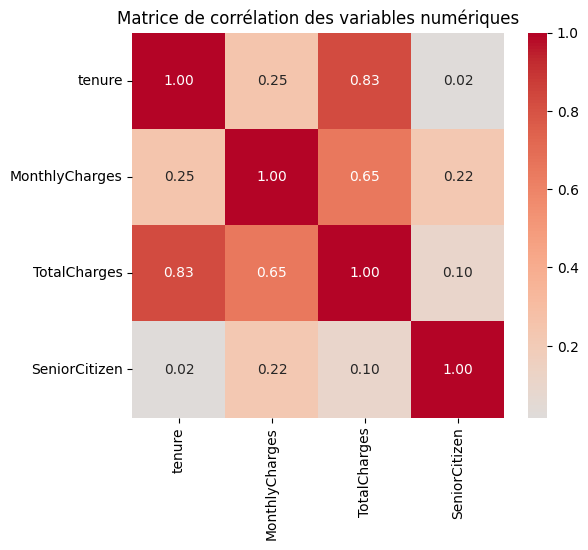

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]]

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

La matrice de corrélation révèle une relation forte entre tenure et TotalCharges (0,83), ce qui s'explique mécaniquement : plus un client reste longtemps abonné, plus il accumule de facturations, indépendamment de tout autre facteur. La corrélation entre MonthlyCharges et TotalCharges est modérée (0,65) : un client qui paie cher chaque mois tend à avoir un total plus élevé, mais cette relation est moins automatique que celle avec tenure, car elle dépend aussi de la durée d'abonnement.

En revanche, tenure et MonthlyCharges sont très peu corrélées (0,25), ce qui indique que l'ancienneté d'un client n'est pas liée à ce qu'il paie chaque mois : un nouveau client peut très bien souscrire une offre coûteuse (fibre + options), tandis qu'un client fidèle peut conserver un forfait basique. Enfin, SeniorCitizen n'affiche quasiment aucune corrélation avec les autres variables numériques (0,02 à 0,22), suggérant que le statut senior influence le churn par d'autres mécanismes que ceux mesurés ici (comportementaux ou liés au type de services souscrits, plutôt que financiers).

Il est important de noter que ces corrélations ne mesurent que des relations linéaires et ne permettent pas de conclure à une causalité. La forte corrélation entre tenure et TotalCharges reflète notamment un lien de calcul plutôt qu'un effet explicatif à interpréter d'un point de vue business.

Cammenbert

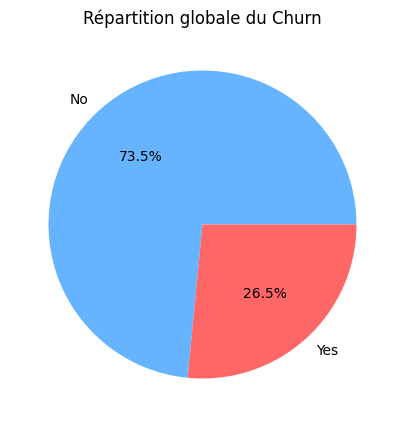

In [ ]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(5, 5))
churn_counts.plot(kind="pie", autopct="%1.1f%%", colors=["#66b3ff", "#ff6666"])
plt.title("Répartition globale du Churn")
plt.ylabel("")
plt.show()

on fait le pivot table

In [ ]:
pivot_churn = df.pivot_table(
    index="Contract",
    columns="InternetService",
    values="Churn",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)

print(pivot_churn.round(2))

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   32.22        54.61  18.89
One year          9.30        19.29   2.47
Two year          1.91         7.23   0.78


Ce tableau croisé révèle un effet d'interaction important entre le type de contrat et le type de connexion internet. Le taux de churn le plus élevé du dataset (54,61%) concerne les clients combinant un contrat mensuel et une connexion fibre optique — soit plus du double du taux observé pour les clients en contrat mensuel avec DSL (32,22%).

Plus intéressant encore, l'effet de la fibre optique sur le churn varie fortement selon l'engagement contractuel : pour un contrat de deux ans, la fibre ne fait passer le churn que de 1,91% à 7,23% (un écart limité), tandis que pour un contrat mensuel, cet écart atteint plus de 22 points. Cela suggère que ce n'est pas la fibre optique en elle-même qui pose problème, mais plutôt la combinaison d'un service coûteux avec un engagement faible, qui laisse au client une grande liberté de résiliation dès qu'il est insatisfait (prix, qualité de service, etc.).

D'un point de vue opérationnel, cela identifie un segment de clients hautement prioritaire pour une stratégie de rétention ciblée : les abonnés fibre optique en contrat mensuel, qui représentent le profil le plus à risque du dataset.

On isole maintenant ce segment à haut risque identifié : contrat mensuel + fibre optique.

In [ ]:
clients_haut_risque = df[
    (df["Contract"] == "Month-to-month") & (df["InternetService"] == "Fiber optic")
]

print("Nombre de clients dans ce segment :", clients_haut_risque.shape[0])
print("Pourcentage du total :", round(clients_haut_risque.shape[0] / df.shape[0] * 100, 2), "%")

print("\nTaux de churn dans ce segment :")
print(clients_haut_risque["Churn"].value_counts(normalize=True) * 100)

print("\nProfil moyen de ce segment :")
print(clients_haut_risque[["tenure", "MonthlyCharges", "TotalCharges"]].describe())

Nombre de clients dans ce segment : 2128
Pourcentage du total : 30.21 %

Taux de churn dans ce segment :
Churn
Yes    54.605263
No     45.394737
Name: proportion, dtype: float64

Profil moyen de ce segment :
            tenure  MonthlyCharges  TotalCharges
count  2128.000000     2128.000000   2128.000000
mean     21.554981       87.021194   1969.714544
std      18.941719       11.198021   1838.216942
min       1.000000       67.750000     68.500000
25%       5.000000       77.987500    400.687500
50%      16.000000       86.000000   1393.650000
75%      34.000000       95.450000   3105.987500
max      72.000000      117.450000   8061.500000


Le segment des clients en contrat mensuel avec fibre optique représente 2 128 clients, soit 30,2% du dataset — une part loin d'être marginale. Le taux de churn y atteint 54,6%, plus du double de la moyenne générale du dataset (26,5%), confirmant qu'il s'agit du profil le plus à risque identifié dans cette analyse.

Le profil moyen de ce segment (tenure de 21,5 mois, charges mensuelles de 87$) montre une ancienneté inférieure à la moyenne générale (32 mois) et des charges mensuelles nettement supérieures (65$ en moyenne sur l'ensemble du dataset). Ce segment combine donc les trois facteurs de risque identifiés précédemment : faible engagement contractuel, connexion coûteuse, et ancienneté réduite.

D'un point de vue opérationnel, ce segment constitue une cible prioritaire pour une stratégie de rétention : représentant près d'un tiers de la clientèle avec un risque de désabonnement démultiplié, une action ciblée (offre de migration vers un contrat engagé, tarif préférentiel, accompagnement renforcé) pourrait avoir un impact significatif sur le taux de churn global de l'entreprise.

### Principaux résultats

L'analyse de 7 043 clients révèle un taux de churn global de 26,5%. Le désabonnement n'est pas réparti uniformément : il se concentre sur des profils précis.

**Facteurs contractuels et financiers.** Le type de contrat est le facteur le plus discriminant : le churn atteint 42,7% en contrat mensuel, contre 11,3% à un an et 2,8% à deux ans. Le mode de paiement par electronic check (45,3%) et la connexion fibre optique (41,9%) sont également associés à un churn élevé. Les clients qui résilient paient en moyenne plus cher chaque mois (74 dollars contre 61 dollars).

**Facteurs liés à l'accompagnement.** L'absence de services de sécurité en ligne ou de support technique multiplie par près de trois le taux de churn (environ 42% contre 15%).

**Facteurs liés à l'ancienneté et au profil.** Les clients qui résilient ont une ancienneté médiane de 10 mois, contre 38 mois pour ceux qui restent : le risque est maximal en début de relation. Les clients seniors, sans partenaire ou sans personnes à charge résilient aussi davantage. À l'inverse, le genre, le service téléphonique et les options de streaming n'ont quasiment pas d'influence.

**Effet d'interaction.** Le tableau croisé Contract x InternetService montre que les facteurs se renforcent mutuellement. Le churn atteint 54,6% pour les clients en contrat mensuel avec fibre optique, alors qu'il n'est que de 7,2% pour la fibre en contrat de deux ans.

### Implications opérationnelles

Le segment "contrat mensuel + fibre optique" regroupe 2 128 clients (30,2% de la base) avec un taux de churn plus de deux fois supérieur à la moyenne. Il constitue la cible prioritaire d'une stratégie de rétention. Trois pistes d'action se dégagent :

1. **Inciter à l'engagement** : proposer aux clients fibre en contrat mensuel une migration vers un contrat annuel ou de deux ans avec un avantage tarifaire.
2. **Accompagner les nouveaux clients** : mettre en place un suivi renforcé durant les premiers mois, période où le risque de résiliation est le plus élevé.
3. **Promouvoir les services de protection** : proposer la sécurité en ligne et le support technique, associés à un churn nettement plus faible.

### Lien avec les objectifs initiaux

Ces résultats répondent à la question de recherche posée en section 2. Les facteurs les plus associés au churn sont le faible engagement contractuel, l'ancienneté réduite, le type de connexion et l'absence de services d'accompagnement. Ils permettent de cibler des segments précis plutôt que d'appliquer une stratégie de rétention générique.